#IncodeVision                  
Name of Student: Uday Pravin Patil

# **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# **Load Dataset**

In [2]:
df = pd.read_csv('/content/Mall_Customers.csv')

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# **Data Preprocessing**

In [3]:
# Check missing values
print(df.isnull().sum())

# Drop CustomerID (not useful for clustering)
df = df.drop(columns=['CustomerID'])

df.head()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


# **Encode Categorical Data**

In [6]:
# Convert Gender to numeric
df['Genre'] = df['Genre'].map({'Male': 0, 'Female': 1})

# **Feature Selection**

In [7]:
# Use important features for clustering
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

# **Feature Scaling**

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# **Finding Optimal Clusters**

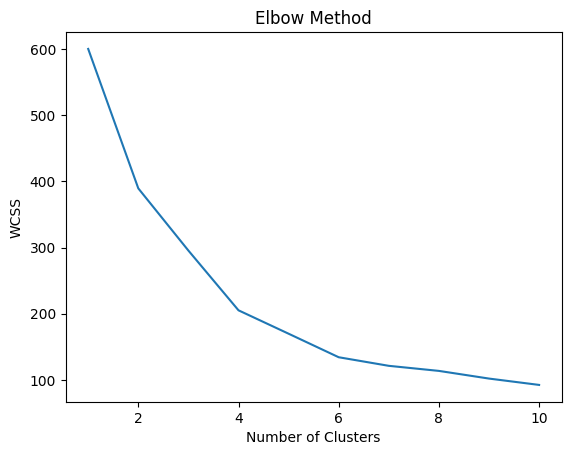

In [9]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

# Applying K-Means

In [10]:
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

# **Visualize Clusters (2D)**

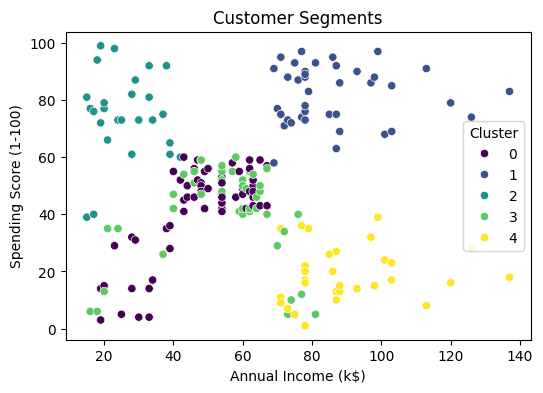

In [11]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    hue=df['Cluster'],
    palette='viridis'
)
plt.title("Customer Segments")
plt.show()

# **Cluster Analysis**

In [12]:
# Mean values per cluster
cluster_summary = df.groupby('Cluster').mean()
print(cluster_summary)

         Genre        Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                              
0          NaN  55.275862           47.620690               41.706897
1          NaN  32.875000           86.100000               81.525000
2          NaN  25.769231           26.115385               74.846154
3          NaN  26.733333           54.311111               40.911111
4          NaN  44.387097           89.774194               18.483871


# **3D Visualization**

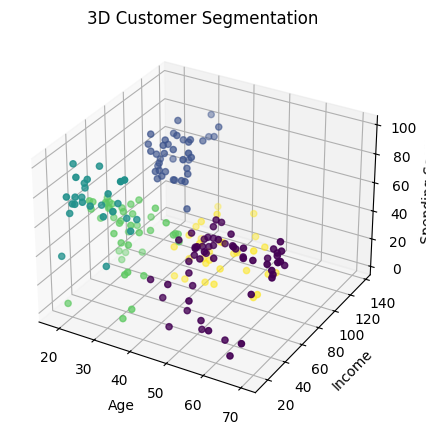

In [13]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(7,5))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df['Age'],
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster']
)

ax.set_xlabel("Age")
ax.set_ylabel("Income")
ax.set_zlabel("Spending Score")

plt.title("3D Customer Segmentation")
plt.show()

# **Predict New Customer Segment**

In [14]:
new_customer = np.array([[30, 60, 70]])  # Age, Income, Score
new_customer_scaled = scaler.transform(new_customer)

cluster = kmeans.predict(new_customer_scaled)

print("Customer belongs to Cluster:", cluster[0])

Customer belongs to Cluster: 1


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
